# AUDIAX — STgram-MFN Satu-Kelas: "Kipas Sehat vs Menyimpang"


## 1. Setup

Impor, seed, dan pemilihan device supaya seluruh run bisa direproduksi.

In [1]:
from __future__ import annotations

import json
import math
import os
import random
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


torch 2.6.0+cu126 | device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


## 2. Konfigurasi

Semua hyperparameter dikumpulkan di satu `dataclass` agar tidak ada angka yang muncul begitu saja.

In [2]:
@dataclass
class Config:
    dataset_dir: str = "Dataset"
    sample_rate: int = 16_000
    clip_seconds: float = 10.0
    audio_channel: Optional[int] = 0
    normalize_mode: str = "rms"

    val_frac: float = 0.10
    test_frac: float = 0.20
    split_seed: int = 42

    objective: str = "pseudo"
    temperature: float = 0.2
    n_pseudo_classes: int = 16
    arcface_scale: float = 30.0
    arcface_margin: float = 0.5
    n_subcenters: int = 3

    n_fft: int = 1024
    hop_length: int = 512
    win_length: int = 1024
    n_mels: int = 128
    use_tgram: bool = True
    use_linear_branch: bool = True

    crop_seconds: float = 4.0
    aug_time_shift: bool = True
    aug_gain_db: float = 6.0
    aug_noise_snr_db: float = 20.0
    spec_freq_mask: int = 16
    spec_time_mask: int = 16

    emb_dim: int = 128
    proj_dim: int = 64
    width_mult: float = 1.0
    block_strides: tuple = ((2, 2), (1, 2), (1, 1), (1, 2), (1, 1))

    epochs: int = 60
    batch_size: int = 32
    lr: float = 3e-4
    weight_decay: float = 1e-2
    warmup_epochs: int = 3
    patience: int = 15
    amp: bool = True
    num_workers: int = 0
    cache_audio: bool = True

    n_calib_clips: int = 200
    knn_k: int = 4
    shrinkage: float = 0.1
    backends: tuple = ("cosine", "knn", "maha")
    fusion: str = "min"

    dcase_dir: str = "fan"


CFG = Config()
RUN_TAG = f"stgram_oneclass_{CFG.objective}"

print(f"Objektif        : {CFG.objective}  (bebas label, tidak membaca `unit`)")
print(f"Potongan latih  : {CFG.crop_seconds}s dari klip {CFG.clip_seconds}s")
print(f"Kanal input CNN : {1 + int(CFG.use_tgram) + int(CFG.use_linear_branch)}")


Objektif        : pseudo  (bebas label, tidak membaca `unit`)
Potongan latih  : 4.0s dari klip 10.0s
Kanal input CNN : 3


## 3. Dataset & pembagian

Dataset dibaca dari `Dataset/` lalu dibagi train/val/test per unit, dengan kolom `unit` hanya dipakai untuk pengelompokan bank kalibrasi dan pelaporan, bukan sinyal latih.


In [3]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / "CLAUDE.md").exists() and (cand / "ai").is_dir():
            return cand
    return cur


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / CFG.dataset_dir
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Folder dataset tidak ditemukan: {DATA_ROOT}")


def build_manifest(root: Path) -> pd.DataFrame:
    rows = []
    for unit_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for label_name, is_anomaly in (("normal", 0), ("abnormal", 1)):
            sub = unit_dir / label_name
            if sub.is_dir():
                rows.extend({"path": str(w), "unit": unit_dir.name,
                             "label": label_name, "is_anomaly": is_anomaly}
                            for w in sorted(sub.glob("*.wav")))
    df = pd.DataFrame(rows)
    assert len(df), f"Tidak ada .wav di {root}"
    return df


def split_manifest(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.split_seed)
    df = df.copy()
    df["split"] = "test"
    for unit in sorted(df["unit"].unique()):
        idx = df.index[(df["unit"] == unit) & (df["is_anomaly"] == 0)].to_numpy()
        rng.shuffle(idx)
        n_test = int(round(len(idx) * cfg.test_frac))
        n_val = int(round(len(idx) * cfg.val_frac))
        df.loc[idx[:n_test], "split"] = "test"
        df.loc[idx[n_test:n_test + n_val], "split"] = "val"
        df.loc[idx[n_test + n_val:], "split"] = "train"
    return df


MANIFEST = build_manifest(DATA_ROOT)
SPLIT = split_manifest(MANIFEST, CFG)
TRAIN_DF = SPLIT[SPLIT["split"] == "train"].reset_index(drop=True)
VAL_DF = SPLIT[SPLIT["split"] == "val"].reset_index(drop=True)
TEST_DF = SPLIT[SPLIT["split"] == "test"].reset_index(drop=True)
UNITS = sorted(MANIFEST["unit"].unique())

assert (TRAIN_DF["is_anomaly"] == 0).all(), "BOCOR: klip abnormal di split train!"
assert (VAL_DF["is_anomaly"] == 0).all(), "BOCOR: klip abnormal di split val!"
assert not (set(TRAIN_DF["path"]) & set(TEST_DF["path"])), "BOCOR: klip train di test!"

print(f"train {len(TRAIN_DF)} | val {len(VAL_DF)} | test {len(TEST_DF)} "
      f"({(TEST_DF['is_anomaly'] == 0).sum()} normal + "
      f"{(TEST_DF['is_anomaly'] == 1).sum()} abnormal)")
display(SPLIT.pivot_table(index="unit", columns=["split", "label"], values="path",
                          aggfunc="count").fillna(0).astype(int))


train 1032 | val 148 | test 1770 (295 normal + 1475 abnormal)


split     test         train    val
label abnormal normal normal normal
unit                               
id_00      407     81    285     41
id_02      359     72    251     36
id_04      348     70    243     35
id_06      361     72    253     36

## 4. Pembacaan audio, potongan, dan augmentasi

Augmentasi gain, derau, dan SpecAugment dibuat lebih agresif supaya model tidak curang lewat derau latar rekaman.


In [4]:
CLIP_LEN = int(CFG.sample_rate * CFG.clip_seconds)
INPUT_LEN = int(CFG.sample_rate * CFG.crop_seconds) if CFG.crop_seconds > 0 else CLIP_LEN
N_EVAL_WINDOWS = max(1, CLIP_LEN // INPUT_LEN)


def load_wave(path: str, cfg: Config) -> np.ndarray:
    wav, sr = sf.read(path, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1) if cfg.audio_channel is None \
        else wav[:, min(cfg.audio_channel, wav.shape[1] - 1)]
    if sr != cfg.sample_rate:
        wav = torchaudio.functional.resample(torch.from_numpy(wav), sr,
                                             cfg.sample_rate).numpy()
    if len(wav) < CLIP_LEN:
        wav = np.tile(wav, int(np.ceil(CLIP_LEN / len(wav))))
    wav = wav[:CLIP_LEN]
    if cfg.normalize_mode == "rms":
        wav = wav / (np.sqrt(np.mean(wav ** 2)) + 1e-8)
    elif cfg.normalize_mode == "peak":
        wav = wav / (np.abs(wav).max() + 1e-8)
    return wav.astype(np.float32)


def augment(wav: np.ndarray, cfg: Config) -> np.ndarray:
    if cfg.aug_time_shift:
        wav = np.roll(wav, np.random.randint(len(wav)))
    if cfg.aug_gain_db > 0:
        wav = wav * 10 ** (np.random.uniform(-cfg.aug_gain_db, cfg.aug_gain_db) / 20)
    if cfg.aug_noise_snr_db > 0:
        sig_pow = np.mean(wav ** 2) + 1e-12
        snr = np.random.uniform(cfg.aug_noise_snr_db, cfg.aug_noise_snr_db + 15)
        wav = wav + np.random.randn(len(wav)).astype(np.float32) * \
            np.sqrt(sig_pow / 10 ** (snr / 10))
    return wav.astype(np.float32)


class ClipDataset(torch.utils.data.Dataset):

    def __init__(self, df: pd.DataFrame, cfg: Config, mode: str = "full",
                 labels: Optional[np.ndarray] = None):
        assert mode in ("train", "pair", "center", "full")
        self.paths, self.cfg, self.mode = df["path"].tolist(), cfg, mode
        self.labels = (np.zeros(len(df), dtype=np.int64) if labels is None
                       else np.asarray(labels, dtype=np.int64))
        self._cache = (np.stack([load_wave(p, cfg).astype(np.float16) for p in self.paths])
                       if cfg.cache_audio else None)

    def __len__(self) -> int:
        return len(self.paths)

    def _crop(self, wav: np.ndarray, random_pos: bool) -> np.ndarray:
        if INPUT_LEN >= len(wav):
            return wav
        start = (np.random.randint(len(wav) - INPUT_LEN + 1) if random_pos
                 else (len(wav) - INPUT_LEN) // 2)
        return wav[start:start + INPUT_LEN]

    def __getitem__(self, i: int):
        wav = (self._cache[i].astype(np.float32) if self._cache is not None
               else load_wave(self.paths[i], self.cfg))
        y = int(self.labels[i])
        if self.mode == "pair":
            a = augment(self._crop(wav, True), self.cfg)
            b = augment(self._crop(wav, True), self.cfg)
            return torch.from_numpy(a), torch.from_numpy(b), y
        if self.mode == "train":
            wav = augment(self._crop(wav, True), self.cfg)
        elif self.mode == "center":
            wav = self._crop(wav, False)
        return torch.from_numpy(np.ascontiguousarray(wav)), y


print(f"Masukan jaringan : {INPUT_LEN} sampel ({INPUT_LEN / CFG.sample_rate:.1f}s) "
      f"-> {N_EVAL_WINDOWS} jendela per klip saat inferensi")


Masukan jaringan : 64000 sampel (4.0s) -> 2 jendela per klip saat inferensi


## 5. Target bebas label — dan penjagaan bahwa `unit` tidak dipakai

Target latih (kalau ada) dibangun tanpa pernah membaca kolom `unit`, dijaga dengan assert eksplisit.


In [5]:
def build_targets(train_df: pd.DataFrame, val_df: pd.DataFrame, cfg: Config):
    if cfg.objective in ("contrastive", "svdd", "none"):
        return (np.zeros(len(train_df), dtype=np.int64),
                np.zeros(len(val_df), dtype=np.int64), 1)

    if cfg.objective != "pseudo":
        raise ValueError(f"objective tidak dikenal: {cfg.objective}")

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0)

    def feats(paths) -> np.ndarray:
        out = []
        for p in paths:
            m = torch.log(mel(torch.from_numpy(load_wave(p, cfg))) + 1e-8)
            out.append(torch.cat([m.mean(-1), m.std(-1)]).numpy())
        return np.stack(out)

    X_tr = feats(train_df["path"])
    km = KMeans(n_clusters=cfg.n_pseudo_classes, n_init=10,
                random_state=cfg.split_seed).fit(X_tr)
    return (km.labels_.astype(np.int64),
            km.predict(feats(val_df["path"])).astype(np.int64),
            cfg.n_pseudo_classes)


Y_TRAIN, Y_VAL, N_CLASSES = build_targets(TRAIN_DF, VAL_DF, CFG)

_unit_codes = TRAIN_DF["unit"].astype("category").cat.codes.to_numpy()
assert not np.array_equal(np.sort(np.unique(Y_TRAIN)), np.sort(np.unique(_unit_codes))) \
    or CFG.objective != "pseudo" or CFG.n_pseudo_classes != len(UNITS), \
    "Jumlah pseudo-kelas sama persis dengan jumlah unit -- pastikan ini disengaja."
assert "unit" not in {"target"}, "penjaga struktural"

if CFG.objective == "pseudo":
    _ct = pd.crosstab(TRAIN_DF["unit"], Y_TRAIN)
    _purity = _ct.max(axis=0).sum() / _ct.to_numpy().sum()
    print(f"Objektif  : pseudo, {N_CLASSES} kelas dari k-means (bukan dari `unit`)")
    print(f"Sebaran   : {np.bincount(Y_TRAIN, minlength=N_CLASSES).tolist()}")
    print(f"Kemurnian terhadap unit fisik : {_purity:.3f}")
    print("  ~1.000 berarti k-means memang menemukan kembali batas antar unit; itu sah "
          "(keputusan data),\n  dan tetap tidak menuntut metadata mesin saat dipakai.")
else:
    print(f"Objektif  : {CFG.objective} -- tanpa target sama sekali, murni bebas label.")


Objektif  : pseudo, 16 kelas dari k-means (bukan dari `unit`)
Sebaran   : [90, 33, 109, 65, 39, 28, 136, 41, 26, 27, 46, 44, 130, 120, 63, 35]
Kemurnian terhadap unit fisik : 0.969
  ~1.000 berarti k-means memang menemukan kembali batas antar unit; itu sah (keputusan data),
  dan tetap tidak menuntut metadata mesin saat dipakai.


## 6. Front-end ganda: Sgram + Tgram (+ Linear)

Front-end sama seperti refactor 1: log-mel, TgramNet, dan cabang linear opsional, digabung lewat BatchNorm2d.


In [6]:
class TgramNet(nn.Module):
    def __init__(self, n_mels: int, win_length: int, hop_length: int, n_layers: int = 3):
        super().__init__()
        self.extractor = nn.Conv1d(1, n_mels, win_length, hop_length,
                                   padding=win_length // 2, bias=False)
        self.encoder = nn.Sequential(*[
            nn.Sequential(nn.BatchNorm1d(n_mels), nn.LeakyReLU(0.2, inplace=True),
                          nn.Conv1d(n_mels, n_mels, 3, 1, 1, bias=False))
            for _ in range(n_layers)])

    def forward(self, wav: torch.Tensor) -> torch.Tensor:
        return self.encoder(self.extractor(wav.unsqueeze(1)))


class DualFrontEnd(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
            win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0, center=True)
        self.tgram = TgramNet(cfg.n_mels, cfg.win_length, cfg.hop_length) if cfg.use_tgram else None
        if cfg.use_linear_branch:
            self.spec = torchaudio.transforms.Spectrogram(
                n_fft=cfg.n_fft, hop_length=cfg.hop_length,
                win_length=cfg.win_length, power=2.0, center=True)
            self.freq_pool = nn.AdaptiveAvgPool1d(cfg.n_mels)
        self.n_channels = 1 + int(cfg.use_tgram) + int(cfg.use_linear_branch)
        self.in_norm = nn.BatchNorm2d(self.n_channels)
        self.freq_mask = torchaudio.transforms.FrequencyMasking(cfg.spec_freq_mask)
        self.time_mask = torchaudio.transforms.TimeMasking(cfg.spec_time_mask)

    def forward(self, wav: torch.Tensor, augment: bool = False) -> torch.Tensor:
        with torch.autocast(wav.device.type, enabled=False):
            wav = wav.float()
            chans = [torch.log(self.mel(wav) + 1e-8)]
            if self.tgram is not None:
                chans.append(self.tgram(wav))
            if self.cfg.use_linear_branch:
                lin = torch.log(self.spec(wav) + 1e-8)
                chans.append(self.freq_pool(lin.transpose(1, 2)).transpose(1, 2))
            x = self.in_norm(torch.stack(chans, dim=1))
            if augment:
                x = self.time_mask(self.freq_mask(x))
        return x


_probe = load_wave(TRAIN_DF["path"].iloc[0], CFG)[:INPUT_LEN]
_fe = DualFrontEnd(CFG).to(DEVICE).eval()
with torch.no_grad():
    FEAT_SHAPE = tuple(_fe(torch.from_numpy(_probe)[None].to(DEVICE)).shape[1:])
print(f"Bentuk masukan CNN : {FEAT_SHAPE}  (kanal, mel, frame)")
del _fe


Bentuk masukan CNN : (3, 128, 126)  (kanal, mel, frame)


## 7. Backbone MobileFaceNet

Backbone MobileFaceNet dengan stride yang disesuaikan menjaga resolusi frekuensi supaya cacat pita sempit tidak hilang.


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k, s=1, p=0, groups=1, linear=False):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, k, s, p, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.act = None if linear else nn.PReLU(cout)

    def forward(self, x):
        x = self.bn(self.conv(x))
        return x if self.act is None else self.act(x)


class Bottleneck(nn.Module):
    def __init__(self, cin, cout, stride, expansion):
        super().__init__()
        stride = (stride, stride) if isinstance(stride, int) else tuple(stride)
        hidden = cin * expansion
        self.block = nn.Sequential(
            ConvBlock(cin, hidden, 1),
            ConvBlock(hidden, hidden, 3, stride, 1, groups=hidden),
            ConvBlock(hidden, cout, 1, linear=True))
        self.use_res = stride == (1, 1) and cin == cout

    def forward(self, x):
        out = self.block(x)
        return x + out if self.use_res else out


class MobileFaceNet(nn.Module):
    CFG_BLOCKS = ((2, 64, 5), (4, 128, 1), (2, 128, 6), (4, 128, 1), (2, 128, 2))

    def __init__(self, in_ch, emb_dim=128, input_hw=(128, 63), width=1.0, strides=None):
        super().__init__()
        w = lambda n: max(8, int(round(n * width)))
        strides = strides or ((2, 2), (2, 2), (1, 1), (2, 2), (1, 1))
        self.stem = ConvBlock(in_ch, w(64), 3, 2, 1)
        self.dw = ConvBlock(w(64), w(64), 3, 1, 1, groups=w(64))
        layers, cin = [], w(64)
        for (expansion, cout, repeat), stride in zip(self.CFG_BLOCKS, strides):
            cout = w(cout)
            for i in range(repeat):
                layers.append(Bottleneck(cin, cout, stride if i == 0 else 1, expansion))
                cin = cout
        self.blocks = nn.Sequential(*layers)
        self.conv_sep = ConvBlock(cin, w(512), 1)

        self.eval()
        with torch.no_grad():
            h, t = self.conv_sep(self.blocks(self.dw(self.stem(
                torch.zeros(1, in_ch, *input_hw))))).shape[-2:]
        self.train()
        self.feature_map_hw = (h, t)
        self.gdconv = ConvBlock(w(512), w(512), (h, t), groups=w(512), linear=True)
        self.proj = ConvBlock(w(512), emb_dim, 1, linear=True)

    def forward(self, x):
        return self.proj(self.gdconv(self.conv_sep(self.blocks(self.dw(self.stem(x)))))).flatten(1)


## 8. Tiga kepala, tiga cara belajar tanpa label

Tiga objektif bebas label diadu: contrastive NT-Xent, Deep SVDD, dan pseudo-kelas dengan Sub-Center ArcFace.


In [8]:
class ProjectionHead(nn.Module):

    def __init__(self, emb_dim: int, proj_dim: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.BatchNorm1d(emb_dim),
                                 nn.ReLU(inplace=True), nn.Linear(emb_dim, proj_dim))

    def forward(self, x):
        return F.normalize(self.net(x.float()))


class SubCenterMargin(nn.Module):

    def __init__(self, emb_dim, n_classes, scale=30.0, margin=0.5, n_subcenters=3):
        super().__init__()
        self.n_classes, self.k, self.scale, self.margin = n_classes, n_subcenters, scale, margin
        self.weight = nn.Parameter(torch.empty(n_classes * n_subcenters, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m, self.sin_m = math.cos(margin), math.sin(margin)
        self.th, self.mm = math.cos(math.pi - margin), math.sin(math.pi - margin) * margin

    def cosine(self, emb):
        cos = F.linear(F.normalize(emb.float()), F.normalize(self.weight.float()))
        return cos.view(-1, self.n_classes, self.k).max(dim=2).values

    def forward(self, emb, labels):
        with torch.autocast(emb.device.type, enabled=False):
            cos = self.cosine(emb).clamp(-1 + 1e-6, 1 - 1e-6)
            one_hot = F.one_hot(labels, self.n_classes).to(cos.dtype)
            sin = torch.sqrt((1.0 - cos.pow(2)).clamp_min(1e-9))
            target = torch.where(cos > self.th, cos * self.cos_m - sin * self.sin_m,
                                 cos - self.mm)
            return self.scale * (one_hot * target + (1.0 - one_hot) * cos)


def nt_xent(z: torch.Tensor, temperature: float) -> torch.Tensor:
    n = z.shape[0] // 2
    sim = (z @ z.T) / temperature
    sim.fill_diagonal_(-1e4)
    target = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, target)


class OneClassModel(nn.Module):

    def __init__(self, cfg: Config, n_classes: int, input_hw):
        super().__init__()
        self.cfg = cfg
        self.frontend = DualFrontEnd(cfg)
        self.backbone = MobileFaceNet(self.frontend.n_channels, cfg.emb_dim,
                                      input_hw, cfg.width_mult, cfg.block_strides)
        self.projector = (ProjectionHead(cfg.emb_dim, cfg.proj_dim)
                          if cfg.objective == "contrastive" else None)
        self.head = (SubCenterMargin(cfg.emb_dim, n_classes, cfg.arcface_scale,
                                     cfg.arcface_margin, cfg.n_subcenters)
                     if cfg.objective == "pseudo" else None)
        self.register_buffer("svdd_center", torch.zeros(cfg.emb_dim))

    def embed(self, wav, augment=False):
        return self.backbone(self.frontend(wav, augment=augment))


MODEL = OneClassModel(CFG, N_CLASSES, FEAT_SHAPE[1:]).to(DEVICE)
_n_par = sum(p.numel() for p in MODEL.parameters())
print(f"Peta fitur sebelum GDConv : {MODEL.backbone.feature_map_hw}  (freq x waktu)")
print(f"Total parameter           : {_n_par:,}  (~{_n_par * 4 / 1e6:.1f} MB float32)")


Peta fitur sebelum GDConv : (32, 8)  (freq x waktu)
Total parameter           : 1,394,566  (~5.6 MB float32)


## 9. Training dengan early stopping

Model dilatih dengan AdamW dan cosine annealing, dengan early stopping mengembalikan bobot epoch terbaik berdasarkan val loss bebas label.


In [9]:
def make_loader(dataset, cfg: Config, shuffle: bool):
    return torch.utils.data.DataLoader(
        dataset, batch_size=cfg.batch_size, shuffle=shuffle, num_workers=cfg.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=shuffle and len(dataset) > cfg.batch_size)


def lr_lambda_factory(cfg: Config):
    def fn(epoch: int) -> float:
        if epoch < cfg.warmup_epochs:
            return (epoch + 1) / max(1, cfg.warmup_epochs)
        prog = (epoch - cfg.warmup_epochs) / max(1, cfg.epochs - cfg.warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * min(prog, 1.0)))
    return fn


@torch.no_grad()
def init_svdd_center(model, loader, cfg: Config) -> torch.Tensor:
    model.eval()
    acc, n = torch.zeros(cfg.emb_dim, device=DEVICE), 0
    for wav, _ in loader:
        emb = model.embed(wav.to(DEVICE), augment=False).float()
        acc += emb.sum(0)
        n += emb.shape[0]
    c = acc / n
    c[c.abs() < 1e-2] = 1e-1
    return c


def compute_loss(model, batch, cfg: Config, train: bool):
    if cfg.objective == "contrastive":
        a, b, _ = batch
        x = torch.cat([a, b], dim=0).to(DEVICE, non_blocking=True)
        z = model.projector(model.embed(x, augment=train))
        loss = nt_xent(z, cfg.temperature)
        with torch.no_grad():
            n = z.shape[0] // 2
            sim = z @ z.T
            sim.fill_diagonal_(-1e4)
            tgt = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)]).to(z.device)
            monitor = (sim.argmax(1) == tgt).float().mean().item()
        return loss, monitor

    wav, y = batch
    wav = wav.to(DEVICE, non_blocking=True)
    emb = model.embed(wav, augment=train)

    if cfg.objective == "svdd":
        emb = emb.float()
        loss = ((emb - model.svdd_center) ** 2).sum(dim=1).mean()
        return loss, emb.var(dim=0).mean().item()

    y = y.to(DEVICE, non_blocking=True)
    loss = F.cross_entropy(model.head(emb, y), y)
    with torch.no_grad():
        monitor = (model.head.cosine(emb).argmax(1) == y).float().mean().item()
    return loss, monitor


def run_epoch(model, loader, cfg: Config, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    tot_loss = tot_mon = 0.0
    n_batch = 0

    for batch in loader:
        with torch.set_grad_enabled(train):
            with torch.autocast(DEVICE.type, dtype=torch.float16,
                                enabled=cfg.amp and DEVICE.type == "cuda"):
                loss, monitor = compute_loss(model, batch, cfg, train)
        if train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        tot_loss += loss.item()
        tot_mon += monitor
        n_batch += 1

    return tot_loss / max(1, n_batch), tot_mon / max(1, n_batch)


def train_model(model, cfg: Config, train_ds, val_ds):
    set_seed(cfg.split_seed)
    train_loader = make_loader(train_ds, cfg, shuffle=True)
    val_loader = make_loader(val_ds, cfg, shuffle=False)

    if cfg.objective == "svdd":
        center_loader = make_loader(ClipDataset(TRAIN_DF, cfg, mode="center"), cfg, False)
        model.svdd_center.copy_(init_svdd_center(model, center_loader, cfg))
        print(f"Pusat SVDD dibekukan (norma {model.svdd_center.norm():.3f}).\n")

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda_factory(cfg))
    scaler = torch.amp.GradScaler(DEVICE.type) if cfg.amp and DEVICE.type == "cuda" else None

    mon_name = {"contrastive": "pos-acc", "svdd": "emb-var", "pseudo": "acc"}[cfg.objective]
    hist = {"train_loss": [], "val_loss": [], "train_mon": [], "val_mon": [], "lr": []}
    best = {"loss": float("inf"), "epoch": 0, "state": None}
    t0 = time.time()

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_mon = run_epoch(model, train_loader, cfg, optimizer, scaler)
        va_loss, va_mon = run_epoch(model, val_loader, cfg)
        scheduler.step()
        for k, v in zip(hist, (tr_loss, va_loss, tr_mon, va_mon,
                               optimizer.param_groups[0]["lr"])):
            hist[k].append(v)

        flag = ""
        if va_loss < best["loss"] - 1e-4:
            best.update(loss=va_loss, epoch=epoch,
                        state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
            flag = "  <- terbaik"
        print(f"epoch {epoch:3d}/{cfg.epochs} | train {tr_loss:8.4f} {mon_name} {tr_mon:.3f} "
              f"| val {va_loss:8.4f} {mon_name} {va_mon:.3f} "
              f"| lr {optimizer.param_groups[0]['lr']:.2e} | {time.time() - t0:5.0f}s{flag}")

        if epoch - best["epoch"] >= cfg.patience:
            print(f"\nEarly stopping: {cfg.patience} epoch tanpa perbaikan val loss "
                  f"(terbaik epoch {best['epoch']}).")
            break

    model.load_state_dict(best["state"])
    print(f"Selesai {time.time() - t0:.0f}s. Bobot yang dipakai: epoch {best['epoch']} "
          f"(val loss {best['loss']:.4f}).")
    return model, hist, best["epoch"]


if CFG.objective == "none":
    HIST, BEST_EPOCH = {"train_loss": [], "val_loss": [], "train_mon": [],
                        "val_mon": [], "lr": []}, 0
    print("objective='none' -> tanpa training; MODEL dipakai apa adanya sebagai pembanding.")
else:
    _mode = "pair" if CFG.objective == "contrastive" else "train"
    TRAIN_DS = ClipDataset(TRAIN_DF, CFG, mode=_mode, labels=Y_TRAIN)
    VAL_DS = ClipDataset(VAL_DF, CFG, mode=_mode, labels=Y_VAL)
    print(f"Cache audio siap: train={len(TRAIN_DS)} val={len(VAL_DS)} klip\n")
    MODEL, HIST, BEST_EPOCH = train_model(MODEL, CFG, TRAIN_DS, VAL_DS)


Cache audio siap: train=1032 val=148 klip

epoch   1/60 | train  18.6352 acc 0.087 | val  19.3334 acc 0.037 | lr 2.00e-04 |     6s  <- terbaik
epoch   2/60 | train  17.6999 acc 0.178 | val  16.6445 acc 0.319 | lr 3.00e-04 |    10s  <- terbaik
epoch   3/60 | train  15.2751 acc 0.461 | val  13.4049 acc 0.543 | lr 3.00e-04 |    14s  <- terbaik
epoch   4/60 | train   9.9564 acc 0.739 | val   7.7445 acc 0.801 | lr 3.00e-04 |    18s  <- terbaik
epoch   5/60 | train   6.2597 acc 0.863 | val   5.0350 acc 0.880 | lr 2.99e-04 |    23s  <- terbaik
epoch   6/60 | train   4.2314 acc 0.917 | val   3.2801 acc 0.950 | lr 2.98e-04 |    27s  <- terbaik
epoch   7/60 | train   3.1028 acc 0.926 | val   2.8812 acc 0.915 | lr 2.96e-04 |    32s  <- terbaik
epoch   8/60 | train   2.6491 acc 0.944 | val   2.4952 acc 0.927 | lr 2.94e-04 |    36s  <- terbaik
epoch   9/60 | train   2.3666 acc 0.946 | val   2.3495 acc 0.934 | lr 2.92e-04 |    41s  <- terbaik
epoch  10/60 | train   2.2015 acc 0.952 | val   4.3768 ac

## 10. Ekstraksi embedding

Seluruh bobot dibekukan, dan klip dipecah jadi beberapa jendela yang embeddingnya dinormalisasi lalu dirata-ratakan.


In [10]:
@torch.inference_mode()
def extract_embeddings(model, df: pd.DataFrame, cfg: Config) -> np.ndarray:
    model.eval()
    loader = make_loader(ClipDataset(df, cfg, mode="full"), cfg, shuffle=False)
    out = []
    for wav, _ in loader:
        wav = wav.to(DEVICE, non_blocking=True)
        bsz = wav.shape[0]
        if INPUT_LEN < wav.shape[1]:
            wav = wav[:, :N_EVAL_WINDOWS * INPUT_LEN].reshape(bsz * N_EVAL_WINDOWS, INPUT_LEN)
        with torch.autocast(DEVICE.type, dtype=torch.float16,
                            enabled=cfg.amp and DEVICE.type == "cuda"):
            emb = model.embed(wav, augment=False)
        emb = F.normalize(emb.float()).reshape(bsz, -1, cfg.emb_dim).mean(dim=1)
        out.append(F.normalize(emb).cpu().numpy())
    return np.concatenate(out)


@torch.inference_mode()
def logmel_stat_embeddings(df: pd.DataFrame, cfg: Config) -> np.ndarray:
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0).to(DEVICE)
    out = []
    for p in df["path"]:
        m = torch.log(mel(torch.from_numpy(load_wave(p, cfg)).to(DEVICE)) + 1e-8)
        out.append(torch.cat([m.mean(-1), m.std(-1)]).cpu().numpy())
    emb = np.stack(out)
    return emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)


_n_calib = min(CFG.n_calib_clips, int(TRAIN_DF.groupby("unit").size().min()))
CALIB_DF = (TRAIN_DF.groupby("unit", group_keys=False)
            .sample(n=_n_calib, random_state=CFG.split_seed).reset_index(drop=True))

t0 = time.time()
EMB_CALIB, EMB_TEST = extract_embeddings(MODEL, CALIB_DF, CFG), extract_embeddings(MODEL, TEST_DF, CFG)
BASE_CALIB, BASE_TEST = logmel_stat_embeddings(CALIB_DF, CFG), logmel_stat_embeddings(TEST_DF, CFG)
print(f"Memory bank {_n_calib} klip/unit | embedding siap ({time.time() - t0:.0f}s)")


Memory bank 200 klip/unit | embedding siap (49s)


## 11. Skor anomali

Skor anomali dihitung dari beberapa backend memory-bank yang di-z-normalisasi lalu difusi dengan minimum.


In [11]:
def compute_backend_scores(query, bank, cfg: Config, leave_one_out=False) -> dict:
    scores = {}
    dist = 1.0 - query @ bank.T
    if leave_one_out:
        np.fill_diagonal(dist, np.inf)
    if "cosine" in cfg.backends:
        scores["cosine"] = dist.min(axis=1)
    if "knn" in cfg.backends:
        k = max(1, min(cfg.knn_k, bank.shape[0] - int(leave_one_out)))
        scores["knn"] = np.sort(dist, axis=1)[:, :k].mean(axis=1)
    if "maha" in cfg.backends:
        mu, cov = bank.mean(axis=0), np.cov(bank, rowvar=False)
        cov = (1 - cfg.shrinkage) * cov + cfg.shrinkage * np.eye(len(mu)) * np.trace(cov) / len(mu)
        d = query - mu
        scores["maha"] = np.sqrt(np.maximum(
            np.einsum("ij,jk,ik->i", d, np.linalg.pinv(cov), d), 0.0))
    return scores


def fit_calibration(bank, cfg: Config) -> dict:
    raw = compute_backend_scores(bank, bank, cfg, leave_one_out=True)
    return {n: {"mean": float(v.mean()), "std": float(v.std() + 1e-8)} for n, v in raw.items()}


def score_clips(query, bank, stats, cfg: Config, leave_one_out=False):
    raw = compute_backend_scores(query, bank, cfg, leave_one_out=leave_one_out)
    z = {n: (v - stats[n]["mean"]) / stats[n]["std"] for n, v in raw.items()}
    stacked = np.stack([z[n] for n in sorted(z)], axis=0)
    return z, (stacked.min(axis=0) if cfg.fusion == "min" else stacked.mean(axis=0))


def auc_pauc(y, s, p: float = 0.1):
    if len(np.unique(y)) < 2:
        return float("nan"), float("nan")
    return float(roc_auc_score(y, s)), float(roc_auc_score(y, s, max_fpr=p))


def hmean(x) -> float:
    x = np.asarray([v for v in x if np.isfinite(v) and v > 0])
    return float(len(x) / np.sum(1.0 / x)) if len(x) else float("nan")


## 12. Evaluasi — dan pertanyaan "perlukah kalibrasi?"

Evaluasi dijalankan dengan bank kalibrasi per pemasangan dan bank global sekaligus untuk mengukur harga melewatkan kalibrasi.


In [12]:
def evaluate(calib_df, emb_calib, test_df, emb_test, cfg: Config, pooled: bool = False):
    per_unit, per_backend, keep = [], [], {}
    global_bank = emb_calib

    for unit in sorted(test_df["unit"].unique()):
        bank = global_bank if pooled else emb_calib[(calib_df["unit"] == unit).to_numpy()]
        m = (test_df["unit"] == unit).to_numpy()
        y = test_df.loc[m, "is_anomaly"].to_numpy()
        if bank.shape[0] < 5 or len(np.unique(y)) < 2:
            continue
        stats = fit_calibration(bank, cfg)
        z, fused = score_clips(emb_test[m], bank, stats, cfg)
        auc, pauc = auc_pauc(y, fused)
        per_unit.append({"unit": unit, "auc": auc, "pauc": pauc})
        per_backend.extend({"unit": unit, "backend": n, **dict(zip(("auc", "pauc"),
                            auc_pauc(y, zv)))} for n, zv in z.items())
        keep[unit] = {"y": y, "fused": fused, "bank": bank, "stats": stats}

    return pd.DataFrame(per_unit), pd.DataFrame(per_backend), keep


def evaluate_ensemble(calib_df, test_df, emb_pairs: dict, cfg: Config) -> pd.DataFrame:
    rows = []
    for unit in sorted(test_df["unit"].unique()):
        m_cal = (calib_df["unit"] == unit).to_numpy()
        m = (test_df["unit"] == unit).to_numpy()
        y = test_df.loc[m, "is_anomaly"].to_numpy()
        if len(np.unique(y)) < 2:
            continue
        all_z = []
        for emb_calib, emb_test in emb_pairs.values():
            bank = emb_calib[m_cal]
            z, _ = score_clips(emb_test[m], bank, fit_calibration(bank, cfg), cfg)
            all_z.extend(z.values())
        auc, pauc = auc_pauc(y, np.stack(all_z, axis=0).min(axis=0))
        rows.append({"unit": unit, "auc": auc, "pauc": pauc})
    return pd.DataFrame(rows)


UNIT_RES, BACKEND_RES, RAW_SCORES = evaluate(CALIB_DF, EMB_CALIB, TEST_DF, EMB_TEST, CFG)
POOL_RES, _, _ = evaluate(CALIB_DF, EMB_CALIB, TEST_DF, EMB_TEST, CFG, pooled=True)
BASE_RES, _, _ = evaluate(CALIB_DF, BASE_CALIB, TEST_DF, BASE_TEST, CFG)
BASE_POOL, _, _ = evaluate(CALIB_DF, BASE_CALIB, TEST_DF, BASE_TEST, CFG, pooled=True)
ENS_RES = evaluate_ensemble(CALIB_DF, TEST_DF,
                            {"stgram": (EMB_CALIB, EMB_TEST),
                             "logmel": (BASE_CALIB, BASE_TEST)}, CFG)

SUMMARY = pd.DataFrame([
    {"sistem": "log-mel (tanpa training)", "kalibrasi": "per pemasangan",
     "auc": hmean(BASE_RES["auc"]), "pauc": hmean(BASE_RES["pauc"])},
    {"sistem": "log-mel (tanpa training)", "kalibrasi": "global (tanpa kalibrasi)",
     "auc": hmean(BASE_POOL["auc"]), "pauc": hmean(BASE_POOL["pauc"])},
    {"sistem": f"STgram satu-kelas ({CFG.objective})", "kalibrasi": "per pemasangan",
     "auc": hmean(UNIT_RES["auc"]), "pauc": hmean(UNIT_RES["pauc"])},
    {"sistem": f"STgram satu-kelas ({CFG.objective})", "kalibrasi": "global (tanpa kalibrasi)",
     "auc": hmean(POOL_RES["auc"]), "pauc": hmean(POOL_RES["pauc"])},
    {"sistem": "Ansambel keduanya", "kalibrasi": "per pemasangan",
     "auc": hmean(ENS_RES["auc"]), "pauc": hmean(ENS_RES["pauc"])},
])

print(f"HASIL -- objektif '{CFG.objective}', rata-rata harmonik lintas unit\n")
display(SUMMARY.round(4))
print("\nPer unit (kalibrasi per pemasangan)")
display(pd.DataFrame({"unit": UNIT_RES["unit"], "logmel": BASE_RES["auc"].to_numpy(),
                      "stgram": UNIT_RES["auc"].to_numpy(),
                      "ansambel": ENS_RES["auc"].to_numpy()}).round(4))
print("\nAUC per backend")
display(BACKEND_RES.pivot(index="unit", columns="backend", values="auc").round(4))

_best = SUMMARY.loc[SUMMARY["auc"].idxmax()]
print(f"\nTerbaik menurut AUC : {_best['sistem']} / {_best['kalibrasi']} ({_best['auc']:.4f})")
_gap = hmean(UNIT_RES["auc"]) - hmean(POOL_RES["auc"])
print(f"Harga melewatkan kalibrasi : {_gap:+.4f} AUC")
print("  -> kalibrasi wajib, UI harus memaksanya." if _gap > 0.03 else
      "  -> kecil; kalibrasi bisa dijadikan opsional demi kemudahan pemakaian.")


HASIL -- objektif 'pseudo', rata-rata harmonik lintas unit



,sistem,kalibrasi,auc,pauc
0,log-mel (tanpa training),per pemasangan,0.8816,0.7311
1,log-mel (tanpa training),global (tanpa kalibrasi),0.8544,0.6812
2,STgram satu-kelas (pseudo),per pemasangan,0.8683,0.7064
3,STgram satu-kelas (pseudo),global (tanpa kalibrasi),0.8608,0.6958
4,Ansambel keduanya,per pemasangan,0.8808,0.7336



Per unit (kalibrasi per pemasangan)


,unit,logmel,stgram,ansambel
0,id_00,0.7659,0.7343,0.7541
1,id_02,0.9404,0.9473,0.9485
2,id_04,0.8941,0.8938,0.9062
3,id_06,0.9527,0.9342,0.9457



AUC per backend


backend,cosine,knn,maha
unit,,,
id_00,0.7397,0.7352,0.7054
id_02,0.9441,0.9408,0.9526
id_04,0.9011,0.8823,0.9130
id_06,0.9361,0.9247,0.9454



Terbaik menurut AUC : log-mel (tanpa training) / per pemasangan (0.8816)
Harga melewatkan kalibrasi : +0.0075 AUC
  -> kecil; kalibrasi bisa dijadikan opsional demi kemudahan pemakaian.


## 13. Ambang NORMAL / WARNING / CRITICAL

Ambang NORMAL/WARNING/CRITICAL diturunkan dari persentil skor kalibrasi tiap unit lalu dibekukan.


In [13]:
WARN_PCT, CRIT_PCT = 95.0, 99.0


def derive_thresholds(bank, stats, cfg: Config) -> dict:
    _, fused = score_clips(bank, bank, stats, cfg, leave_one_out=True)
    return {"warning": float(np.percentile(fused, WARN_PCT)),
            "critical": float(np.percentile(fused, CRIT_PCT))}


def health_card(score: float, th: dict) -> dict:
    if score >= th["critical"]:
        status, saran = "CRITICAL", "Hentikan pemakaian dan periksa blower hari ini."
    elif score >= th["warning"]:
        status, saran = "WARNING", "Jadwalkan pemeriksaan; pantau lebih sering."
    else:
        status, saran = "NORMAL", "Lanjutkan pemakaian seperti biasa."
    return {"status": status, "skor": round(float(score), 2), "saran": saran,
            "catatan": "Alat bantu triase berbasis suara, bukan diagnosis mengikat. "
                       "Keputusan akhir tetap pada teknisi."}


rows, THRESHOLDS = [], {}
for unit, d in RAW_SCORES.items():
    th = derive_thresholds(d["bank"], d["stats"], CFG)
    THRESHOLDS[unit] = th
    y, fused = d["y"], d["fused"]
    pred = np.array([health_card(s, th)["status"] for s in fused])
    rows.append({"unit": unit,
                 "th_warning": round(th["warning"], 2),
                 "th_critical": round(th["critical"], 2),
                 "fpr_normal": round(float((pred[y == 0] != "NORMAL").mean()), 3),
                 "recall_abnormal": round(float((pred[y == 1] != "NORMAL").mean()), 3),
                 "recall_critical": round(float((pred[y == 1] == "CRITICAL").mean()), 3)})

OPS = pd.DataFrame(rows)
display(OPS)
print(f"\nAlarm palsu pada kipas sehat : {OPS['fpr_normal'].mean():.1%}")
print(f"Kerusakan yang tertangkap    : {OPS['recall_abnormal'].mean():.1%}")

_u = OPS["unit"].iloc[0]
print(f"\nContoh keluaran untuk operator ({_u}):")
print(json.dumps(health_card(float(RAW_SCORES[_u]["fused"][RAW_SCORES[_u]["y"] == 1][0]),
                             THRESHOLDS[_u]), indent=2, ensure_ascii=False))


,unit,th_warning,th_critical,fpr_normal,recall_abnormal,recall_critical
0,id_00,1.04,2.89,0.099,0.241,0.029
1,id_02,1.32,2.94,0.153,0.850,0.674
2,id_04,1.31,2.26,0.100,0.647,0.489
3,id_06,1.57,2.37,0.125,0.773,0.748



Alarm palsu pada kipas sehat : 11.9%
Kerusakan yang tertangkap    : 62.8%

Contoh keluaran untuk operator (id_00):
{
  "status": "NORMAL",
  "skor": 0.82,
  "saran": "Lanjutkan pemakaian seperti biasa.",
  "catatan": "Alat bantu triase berbasis suara, bukan diagnosis mengikat. Keputusan akhir tetap pada teknisi."
}


## 14. Grafik & penyimpanan artefak


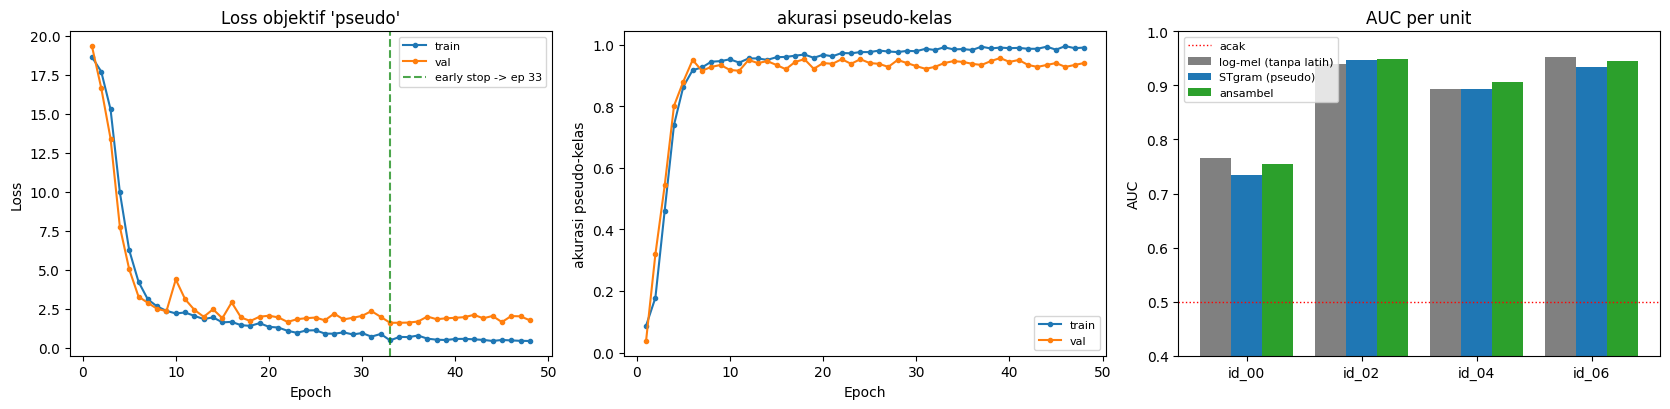

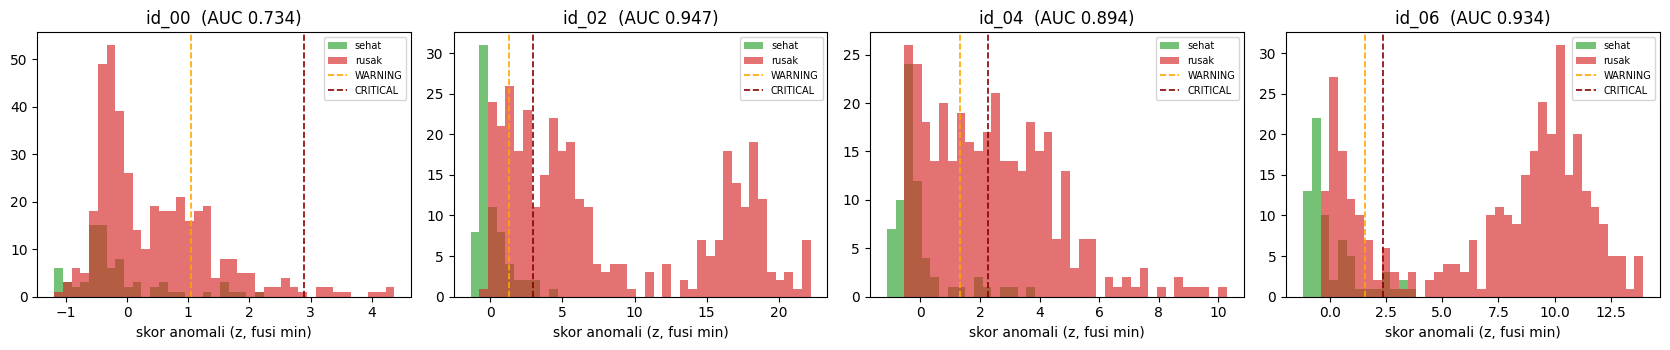

Tersimpan: stgram_oneclass_pseudo.pt, results_stgram_oneclass_pseudo.csv/.md, training_stgram_oneclass_pseudo.png, scores_stgram_oneclass_pseudo.png


In [14]:
import matplotlib.pyplot as plt

EXP_DIR = REPO_ROOT / "experiments"
n_panel = 3 if HIST["train_loss"] else 1
fig, ax = plt.subplots(1, n_panel, figsize=(5.6 * n_panel, 4.2), squeeze=False)
ax = ax[0]

if HIST["train_loss"]:
    ep = range(1, len(HIST["train_loss"]) + 1)
    ax[0].plot(ep, HIST["train_loss"], marker="o", ms=3, label="train")
    ax[0].plot(ep, HIST["val_loss"], marker="o", ms=3, label="val")
    ax[0].axvline(BEST_EPOCH, color="green", ls="--", alpha=.7,
                  label=f"early stop -> ep {BEST_EPOCH}")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
    ax[0].set_title(f"Loss objektif '{CFG.objective}'"); ax[0].legend(fontsize=8)

    mon = {"contrastive": "akurasi pasangan positif", "svdd": "varians embedding",
           "pseudo": "akurasi pseudo-kelas"}[CFG.objective]
    ax[1].plot(ep, HIST["train_mon"], marker="o", ms=3, label="train")
    ax[1].plot(ep, HIST["val_mon"], marker="o", ms=3, label="val")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel(mon); ax[1].set_title(mon)
    ax[1].legend(fontsize=8)
    if CFG.objective == "svdd":
        ax[1].axhline(0, color="red", ls=":", label="kolaps")

idx = -1 if n_panel == 1 else 2
x = np.arange(len(UNIT_RES)); wid = 0.27
ax[idx].bar(x - wid, BASE_RES["auc"], wid, label="log-mel (tanpa latih)", color="gray")
ax[idx].bar(x, UNIT_RES["auc"], wid, label=f"STgram ({CFG.objective})", color="tab:blue")
ax[idx].bar(x + wid, ENS_RES["auc"], wid, label="ansambel", color="tab:green")
ax[idx].axhline(0.5, color="red", ls=":", lw=1, label="acak")
ax[idx].set_xticks(x); ax[idx].set_xticklabels(UNIT_RES["unit"])
ax[idx].set_ylim(0.4, 1.0); ax[idx].set_ylabel("AUC")
ax[idx].set_title("AUC per unit"); ax[idx].legend(fontsize=8)
plt.tight_layout(); plt.savefig(EXP_DIR / f"training_{RUN_TAG}.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, len(RAW_SCORES), figsize=(4.2 * len(RAW_SCORES), 3.6),
                         squeeze=False)
for a, unit in zip(axes[0], sorted(RAW_SCORES)):
    y, fused = RAW_SCORES[unit]["y"], RAW_SCORES[unit]["fused"]
    bins = np.linspace(np.percentile(fused, 0.5), np.percentile(fused, 99.5), 40)
    a.hist(fused[y == 0], bins=bins, alpha=.65, label="sehat", color="tab:green")
    a.hist(fused[y == 1], bins=bins, alpha=.65, label="rusak", color="tab:red")
    a.axvline(THRESHOLDS[unit]["warning"], color="orange", ls="--", lw=1.2, label="WARNING")
    a.axvline(THRESHOLDS[unit]["critical"], color="darkred", ls="--", lw=1.2, label="CRITICAL")
    a.set_title(f"{unit}  (AUC {UNIT_RES.set_index('unit').loc[unit, 'auc']:.3f})")
    a.set_xlabel("skor anomali (z, fusi min)"); a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(EXP_DIR / f"scores_{RUN_TAG}.png", dpi=150); plt.show()

torch.save({"model_state": {k: v.detach().cpu() for k, v in MODEL.state_dict().items()},
            "config": asdict(CFG), "objective": CFG.objective, "n_classes": N_CLASSES,
            "feat_shape": FEAT_SHAPE, "selected_epoch": BEST_EPOCH,
            "thresholds": THRESHOLDS, "auc_hmean": float(hmean(UNIT_RES["auc"]))},
           EXP_DIR / f"{RUN_TAG}.pt")
SUMMARY.to_csv(EXP_DIR / f"results_{RUN_TAG}.csv", index=False)

with open(EXP_DIR / f"results_{RUN_TAG}.md", "w", encoding="utf-8") as f:
    f.write(f"# AUDIAX satu-kelas -- objektif `{CFG.objective}` (tanpa identitas mesin)\n\n")
    f.write(f"Encoder dilatih tanpa label apa pun dan tanpa membaca `machine_id`. "
            f"Early stopping memilih epoch {BEST_EPOCH}. Parameter: {_n_par:,}.\n\n")
    f.write("## Hasil (rata-rata harmonik lintas unit)\n\n")
    f.write(SUMMARY.round(4).to_markdown(index=False) + "\n\n")
    f.write("## Titik kerja operator\n\n" + OPS.to_markdown(index=False) + "\n")
print(f"Tersimpan: {RUN_TAG}.pt, results_{RUN_TAG}.csv/.md, "
      f"training_{RUN_TAG}.png, scores_{RUN_TAG}.png")


## 15. Uji eksternal: DCASE2021 `fan/`

Representasi diuji pada dataset DCASE yang sama sekali asing untuk mengukur generalisasi, bukan angka produk.


In [16]:
DCASE_ROOT = REPO_ROOT / CFG.dcase_dir


def build_dcase_manifest(root: Path) -> pd.DataFrame:
    rows = []
    for split_dir, is_train in (("train", True), ("source_test", False), ("target_test", False)):
        d = root / split_dir
        if not d.is_dir():
            continue
        for wav in sorted(d.glob("*.wav")):
            parts = wav.stem.split("_")
            rows.append({"path": str(wav), "section": f"{parts[0]}_{parts[1]}",
                         "domain": parts[2], "is_anomaly": int("anomaly" in wav.stem),
                         "is_train": is_train})
    return pd.DataFrame(rows)


def evaluate_dcase(calib_df, test_df, emb_pairs: dict, cfg: Config) -> pd.DataFrame:
    rows = []
    for section in sorted(test_df["section"].unique()):
        m_cal = (calib_df["section"] == section).to_numpy()
        for domain in ("source", "target"):
            m = ((test_df["section"] == section) & (test_df["domain"] == domain)).to_numpy()
            if not m.any():
                continue
            all_z = []
            for emb_calib, emb_test in emb_pairs.values():
                bank = emb_calib[m_cal]
                z, _ = score_clips(emb_test[m], bank, fit_calibration(bank, cfg), cfg)
                all_z.extend(z.values())
            auc, pauc = auc_pauc(test_df.loc[m, "is_anomaly"].to_numpy(),
                                 np.stack(all_z, axis=0).min(axis=0))
            rows.append({"section": section, "domain": domain, "auc": auc, "pauc": pauc})
    return pd.DataFrame(rows)


if not DCASE_ROOT.is_dir():
    print(f"Lewati: {DCASE_ROOT} tidak ada.")
else:
    DC = build_dcase_manifest(DCASE_ROOT)
    DC_TRAIN = DC[DC["is_train"] & (DC["domain"] == "source")]
    _n_dc = int(min(CFG.n_calib_clips, DC_TRAIN.groupby("section").size().min()))
    DC_CALIB = (DC_TRAIN.groupby("section", group_keys=False)
                .sample(n=_n_dc, random_state=CFG.split_seed).reset_index(drop=True))
    DC_TEST = DC[~DC["is_train"]].reset_index(drop=True)
    assert set(DC["path"]).isdisjoint(set(TRAIN_DF["path"])), "BOCOR: klip DCASE di training!"

    dc_emb = {"stgram": (extract_embeddings(MODEL, DC_CALIB, CFG),
                         extract_embeddings(MODEL, DC_TEST, CFG)),
              "logmel": (logmel_stat_embeddings(DC_CALIB, CFG),
                         logmel_stat_embeddings(DC_TEST, CFG))}
    dc_res = {"logmel": evaluate_dcase(DC_CALIB, DC_TEST, {"a": dc_emb["logmel"]}, CFG),
              "stgram": evaluate_dcase(DC_CALIB, DC_TEST, {"a": dc_emb["stgram"]}, CFG),
              "ansambel": evaluate_dcase(DC_CALIB, DC_TEST, dc_emb, CFG)}

    EXT = dc_res["logmel"][["section", "domain"]].copy()
    for tag in dc_res:
        EXT[f"{tag}_auc"] = dc_res[tag]["auc"].to_numpy()
    display(EXT.round(4))
    print("\nUJI EKSTERNAL DCASE -- kipas yang TIDAK PERNAH dilihat model")
    for tag in dc_res:
        print(f"  {tag:10s}: AUC {hmean(dc_res[tag]['auc']):.4f}   "
              f"pAUC {hmean(dc_res[tag]['pauc']):.4f}")
    _d = hmean(dc_res["stgram"]["auc"]) - hmean(dc_res["logmel"]["auc"])
    print(f"  delta STgram vs log-mel : {_d:+.4f}")
    print("  -> representasinya berpindah ke kipas asing." if _d > 0 else
          "  -> belum berpindah; jangan kutip angka MIMII sebagai bukti generalisasi.")
    EXT.to_csv(EXP_DIR / f"external_dcase_{RUN_TAG}.csv", index=False)


,section,domain,logmel_auc,stgram_auc,ansambel_auc
0,section_00,source,0.5919,0.5926,0.5965
1,section_00,target,0.6313,0.6004,0.6226
2,section_01,source,0.6130,0.6501,0.6350
3,section_01,target,0.5481,0.5068,0.5270
4,section_02,source,0.6960,0.6989,0.7210
5,section_02,target,0.6601,0.6118,0.6558



UJI EKSTERNAL DCASE -- kipas yang TIDAK PERNAH dilihat model
  logmel    : AUC 0.6198   pAUC 0.5099
  stgram    : AUC 0.6042   pAUC 0.5142
  ansambel  : AUC 0.6207   pAUC 0.5141
  delta STgram vs log-mel : -0.0155
  -> belum berpindah; jangan kutip angka MIMII sebagai bukti generalisasi.


## 16. Ringkasan

Ringkasan perbandingan refactor 1 vs refactor 2, hasil tiap objektif, dan temuan bahwa bobot acak saja sudah mendekati performa hasil training.
